# Module 1 — Outlier Detection

## Dataset: Child Mind Institute — Problematic Internet Use

---

## Step 00: Setup & Load

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA 
from isotree import IsolationForest

In [10]:
df = pd.read_csv("../processed_data/cmi_preprocessed.csv", index_col=0)
print(f"Shape: {df.shape}")
df.head()

Shape: (8259, 19)


,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-HeartRate,BIA-BIA_Activity_Level_num,BIA-BIA_BMI,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Frame_num,PreInt_EduHx-computerinternet_hoursday,sii,Physical-Mean_arterial_pressure,BIA-FM,FGC-Fitness_score,PAQ_Combined
0,5.0,0,51.0,116.840000,23.042474,84.333333,2.0,16.8792,1492.00,41.5862,13.817700,3.06143,1.0,3.0,2.0,82.555556,2.123081,3,2.500000
1,9.0,0,60.5,121.920000,20.865232,70.000000,2.0,14.0371,1498.65,42.0291,12.825400,1.21172,1.0,0.0,0.0,90.666667,0.828527,4,2.175000
2,10.0,1,71.0,143.510000,34.291555,94.000000,3.0,17.9665,1863.98,61.0662,14.092500,3.69863,2.0,2.0,0.0,82.333333,5.546522,5,2.088333
3,9.0,0,71.0,142.240000,37.013107,97.000000,3.0,18.2943,1923.44,62.7757,14.074000,4.22033,2.0,0.0,1.0,79.000000,6.967458,4,2.230500
4,18.0,1,65.0,137.862733,34.926584,89.000000,3.0,17.9665,1863.98,61.0662,15.141363,3.69863,2.0,1.0,0.0,83.388889,5.649235,5,1.885000


---
## Step 01: Extended Isolation Forest

In [11]:
# Fit Extended Isolation Forest (ndim = n_features for fully extended hyperplane splits)
eif = IsolationForest(
    ndim=df.shape[1],
    ntrees=500,
    sample_size=256,
    random_seed=42,
    nthreads=-1,
)
eif.fit(df)

/home/giulio/Uni/Master/DataMining2/.venv/lib/python3.14/site-packages/isotree/__init__.py:1737: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  X_cat = X.select_dtypes(include = [pd.CategoricalDtype, "object", "bool"])
/home/giulio/Uni/Master/DataMining2/.venv/lib/python3.14/site-packages/isotree/__init__.py:1757: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  self.cols_categ_    = X.select_dtypes(include = [pd.CategoricalDtype, "object", "bool"]).columns.to_numpy(copy=True)


,"sample_size sample_size: str ""auto"", int, float(0,1), or NoneSample size of the data sub-samples with which each binary tree will be built. If passing 'None', eachtree will be built using the full data. Recommended value in [1]_, [2]_, [3]_ is 256, whilethe default value in the author's code in [5]_ is 'None' here.If passing ""auto"", will use the full number of rows in the data, up to 10,000 (i.e.will take 'sample_size=min(nrows(X), 10000)') **when calling fit**, and the full amountof rows in the data **when calling the variants** ``fit_predict`` or ``fit_transform``.If passing ``None``, will take the full number of rows in the data (no sub-sampling).If passing a number between zero and one, will assume it means taking a sample size that representsthat proportion of the rows in the data.Hint: seeing a distribution of scores which is on average too far below 0.5 could mean that themodel needs more trees and/or bigger samples to reach convergence (unless using non-randomsplits, in which case the distribution is likely to be centered around a much lower number),or that the distributions in the data are too skewed for random uniform splits.",256
,"ntrees ntrees: intNumber of binary trees to build for the model. Recommended value in [1]_ is 100, while the default value in theauthor's code in [5]_ is 10. In general, the number of trees required for good resultsis higher when (a) there are many columns, (b) there are categorical variables, (c) categorical variables have manycategories, (d) `ndim` is high, (e) ``prob_pick_pooled_gain`` is used, (f) ``scoring_metric=""density""``or ``scoring_metric=""boxed_density""`` are used.Hint: seeing a distribution of scores which is on average too far below 0.5 could mean that themodel needs more trees and/or bigger samples to reach convergence (unless using non-randomsplits, in which case the distribution is likely to be centered around a much lower number),or that the distributions in the data are too skewed for random uniform splits.",500
,"ndim ndim: intNumber of columns to combine to produce a split. If passing 1, will produce the single-variable model describedin [1]_ and [2]_, while if passing values greater than 1, will produce the extended model described in [3]_ and [4]_.Recommended value in [4]_ is 2, while [3]_ recommends a low value such as 2 or 3. Models with values higher than 1are referred hereafter as the extended model (as in [3]_).Note that, when using ``ndim>1`` plus ``standardize_data=True``, the variables are standardized ateach step as suggested in [4]_, which makes the models slightly different than in [3]_.In general, when the data has categorical variables, models with ``ndim=1`` plus``categ_split_type=""single_categ""`` tend to produce better results, while models ``ndim>1``tend to produce better results for numerical-only data, especially in the presence of missing values.",19
,"ntry ntry: intWhen using any of ``prob_pick_pooled_gain``, ``prob_pick_avg_gain``, ``prob_pick_full_gain``, ``prob_pick_dens``, how many variables (with ``ndim=1``)or linear combinations (with ``ndim>1``) to try for determining the best one according to gain.Recommended value in reference [4]_ is 10 (with ``prob_pick_avg_gain``, for outlier detection), while therecommended value in reference [11]_ is 1 (with ``prob_pick_pooled_gain``, for outlier detection), and therecommended value in reference [9]_ is 10 to 20 (with ``prob_pick_pooled_gain``, for missing value imputations).",1
,"categ_cols categ_cols: None or array-likeColumns that hold categorical features, when the data is passed as an array or matrix.Categorical columns should contain only integer values with a continuous numeration starting at zero,with negative values and NaN taken as missing,and the array or list passed here should correspond to the column numbers, with numeration startingat zero. The maximum categorical value should not exceed 'INT_MAX' (typically :math:`2^{31}-1`).This might be passed either at construction time

In [12]:
# Compute anomaly scores (higher = more anomalous)
scores = eif.predict(df, output="score")

# Identify top 1% outliers
threshold = np.percentile(scores, 99)
outlier_mask = scores >= threshold

n_outliers = outlier_mask.sum()
print(f"Anomaly score threshold (99th percentile): {threshold:.4f}")
print(f"Number of outliers (top 1%): {n_outliers} / {len(df)} ({n_outliers/len(df)*100:.2f}%)")

Anomaly score threshold (99th percentile): 0.6069
Number of outliers (top 1%): 83 / 8259 (1.00%)


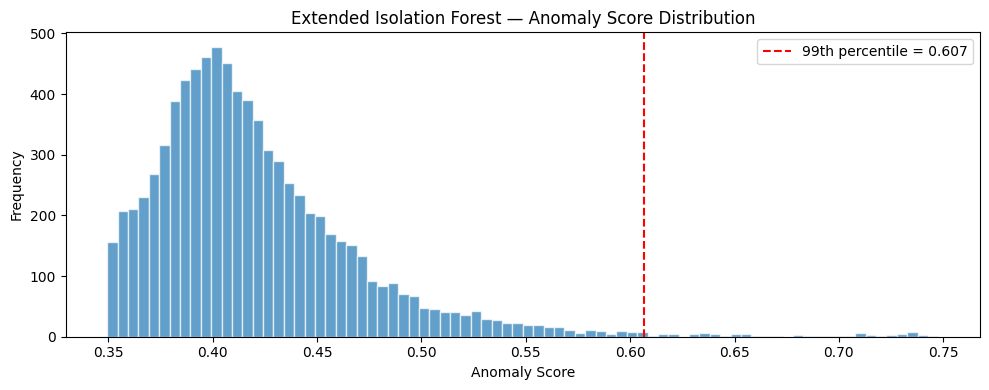

In [13]:
# Score distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(scores, bins=80, edgecolor="white", alpha=0.7)
ax.axvline(threshold, color="red", linestyle="--", label=f"99th percentile = {threshold:.3f}")
ax.set_xlabel("Anomaly Score")
ax.set_ylabel("Frequency")
ax.set_title("Extended Isolation Forest — Anomaly Score Distribution")
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 02: Outlier Visualization via PCA

Project the data onto the first two principal components and highlight the detected outliers.

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# PCA (3 components for both 2D and 3D plots)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

ev = pca.explained_variance_ratio_
print(f"Explained variance — PC1: {ev[0]:.2%}, PC2: {ev[1]:.2%}")
print(f"Cumulative (2 PCs): {ev.sum():.2%}")

Explained variance — PC1: 25.66%, PC2: 7.18%
Cumulative (2 PCs): 32.84%


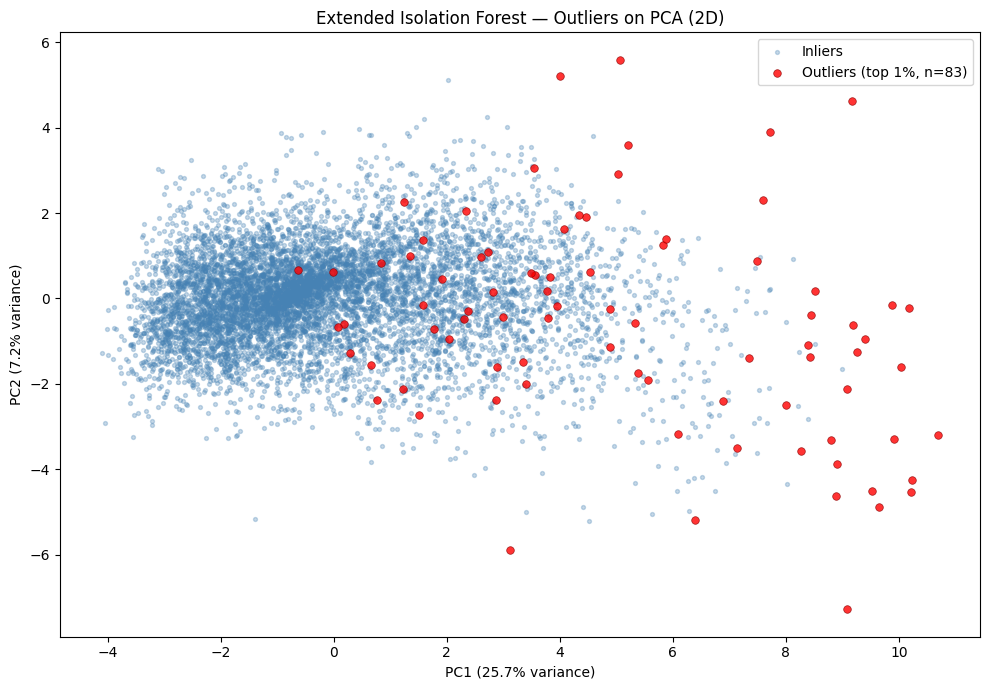

In [15]:
# 2D scatter plot (PC1 vs PC2)
fig, ax = plt.subplots(figsize=(10, 7))

inliers = ~outlier_mask
ax.scatter(X_pca[inliers, 0], X_pca[inliers, 1],
           c="steelblue", s=8, alpha=0.3, label="Inliers")
ax.scatter(X_pca[outlier_mask, 0], X_pca[outlier_mask, 1],
           c="red", s=30, alpha=0.8, edgecolors="darkred", linewidths=0.5,
           label=f"Outliers (top 1%, n={n_outliers})")

ax.set_xlabel(f"PC1 ({ev[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({ev[1]:.1%} variance)")
ax.set_title("Extended Isolation Forest — Outliers on PCA (2D)")
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 03: Outlier Profile

Inspect which features drive the detected outliers by comparing their statistics to the overall dataset.

In [16]:
# Compare mean of outliers vs. inliers (in standardized z-score terms)
df_outliers = df[outlier_mask]
df_inliers = df[~outlier_mask]

comparison = pd.DataFrame({
    "Mean (all)": df.mean(),
    "Mean (outliers)": df_outliers.mean(),
    "Mean (inliers)": df_inliers.mean(),
    "Std (all)": df.std(),
})
comparison["Z-diff"] = (comparison["Mean (outliers)"] - comparison["Mean (all)"]) / comparison["Std (all)"]
comparison.sort_values("Z-diff", key=abs, ascending=False)

,Mean (all),Mean (outliers),Mean (inliers),Std (all),Z-diff
BIA-BIA_FFMI,14.827909,38.691482,14.585654,5.337194,4.471184
BIA-BIA_FFM,74.883044,1026.149025,65.226112,223.960504,4.247472
BIA-BIA_DEE,1941.091711,10192.899523,1857.322136,2494.576425,3.307899
BIA-FM,9.572568,36.497660,9.299234,11.276212,2.387778
BIA-BIA_BMI,18.834709,25.850908,18.763482,3.546305,1.978454
BIA-BIA_FMI,4.621003,9.654051,4.569910,2.883157,1.745673
Physical-Weight,38.363947,63.676884,38.106979,16.830201,1.504019
Physical-Height,144.998715,166.655112,144.778866,18.155315,1.192841
Basic_Demos-Age,10.226178,13.000000,10.198019,3.556817,0.779861
BIA-BIA_Frame_num,1.750938,2.168675,1.746698,0.544094,0.767766


---
## Step 04: Export Datasets

In [17]:
# Dataset with anomaly scores and outlier flag
df_scored = df.copy()
df_scored["anomaly_score"] = scores
df_scored["is_outlier"] = outlier_mask.astype(int)
df_scored.to_csv("../eif_data/cmi_eif_scores.csv")
print(f"Scored dataset: {df_scored.shape}")
df_scored

Scored dataset: (8259, 21)


,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-HeartRate,BIA-BIA_Activity_Level_num,BIA-BIA_BMI,BIA-BIA_DEE,BIA-BIA_FFM,...,BIA-BIA_FMI,BIA-BIA_Frame_num,PreInt_EduHx-computerinternet_hoursday,sii,Physical-Mean_arterial_pressure,BIA-FM,FGC-Fitness_score,PAQ_Combined,anomaly_score,is_outlier
0,5.0,0,51.000000,116.840000,23.042474,84.333333,2.0,16.879200,1492.000000,41.586200,...,3.061430,1.0,3.0,2.0,82.555556,2.123081,3,2.500000,0.440392,0
1,9.0,0,60.500000,121.920000,20.865232,70.000000,2.0,14.037100,1498.650000,42.029100,...,1.211720,1.0,0.0,0.0,90.666667,0.828527,4,2.175000,0.408864,0
2,10.0,1,71.000000,143.510000,34.291555,94.000000,3.0,17.966500,1863.980000,61.066200,...,3.698630,2.0,2.0,0.0,82.333333,5.546522,5,2.088333,0.367726,0
3,9.0,0,71.000000,142.240000,37.013107,97.000000,3.0,18.294300,1923.440000,62.775700,...,4.220330,2.0,0.0,1.0,79.000000,6.967458,4,2.230500,0.371667,0
4,18.0,1,65.000000,137.862733,34.926584,89.000000,3.0,17.966500,1863.980000,61.066200,...,3.698630,2.0,1.0,0.0,83.388889,5.649235,5,1.885000,0.395236,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8254,16.0,1,66.666667,178.714400,65.271889,66.000000,4.0,23.853830,2827.366295,115.712153,...,5.254770,2.0,2.0,0.0,82.833333,24.553407,6,2.695000,0.469490,0
8255,7.0,1,65.166667,117.017800,22.226008,82.500000,1.0,14.813292,1490.847845,42.546078,...,1.094562,1.0,0.0,0.0,73.722222,0.705448,6,2.501667,0.423421,0
8256,10.0,1,69.500000,142.570200,21.681698,80.500000,3.0,16.157808,1678.330810,49.863069,...,2.644989,1.0,0.0,1.0,79.833333,1.658913,3,2.500000,0.388118,0
8257,15.0,1,55.500000,162.026600,45.132404,87.500000,2.0,19.665279,1674.735823,80.716700,...,5.881968,2.0,1.0,2.0,79.666667,12.058771,5,2.000000,0.416639,0


In [18]:
# Dataset without outliers
df_clean = df[~outlier_mask]
df_clean.to_csv("../eif_data/cmi_no_outliers.csv")
print(f"Clean dataset (outliers removed): {df_clean.shape}")
df_clean

Clean dataset (outliers removed): (8176, 19)


,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-HeartRate,BIA-BIA_Activity_Level_num,BIA-BIA_BMI,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Frame_num,PreInt_EduHx-computerinternet_hoursday,sii,Physical-Mean_arterial_pressure,BIA-FM,FGC-Fitness_score,PAQ_Combined
0,5.0,0,51.000000,116.840000,23.042474,84.333333,2.0,16.879200,1492.000000,41.586200,13.817700,3.061430,1.0,3.0,2.0,82.555556,2.123081,3,2.500000
1,9.0,0,60.500000,121.920000,20.865232,70.000000,2.0,14.037100,1498.650000,42.029100,12.825400,1.211720,1.0,0.0,0.0,90.666667,0.828527,4,2.175000
2,10.0,1,71.000000,143.510000,34.291555,94.000000,3.0,17.966500,1863.980000,61.066200,14.092500,3.698630,2.0,2.0,0.0,82.333333,5.546522,5,2.088333
3,9.0,0,71.000000,142.240000,37.013107,97.000000,3.0,18.294300,1923.440000,62.775700,14.074000,4.220330,2.0,0.0,1.0,79.000000,6.967458,4,2.230500
4,18.0,1,65.000000,137.862733,34.926584,89.000000,3.0,17.966500,1863.980000,61.066200,15.141363,3.698630,2.0,1.0,0.0,83.388889,5.649235,5,1.885000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8254,16.0,1,66.666667,178.714400,65.271889,66.000000,4.0,23.853830,2827.366295,115.712153,17.598238,5.254770,2.0,2.0,0.0,82.833333,24.553407,6,2.695000
8255,7.0,1,65.166667,117.017800,22.226008,82.500000,1.0,14.813292,1490.847845,42.546078,13.623619,1.094562,1.0,0.0,0.0,73.722222,0.705448,6,2.501667
8256,10.0,1,69.500000,142.570200,21.681698,80.500000,3.0,16.157808,1678.330810,49.863069,13.524840,2.644989,1.0,0.0,1.0,79.833333,1.658913,3,2.500000
8257,15.0,1,55.500000,162.026600,45.132404,87.500000,2.0,19.665279,1674.735823,80.716700,16.197522,5.881968,2.0,1.0,2.0,79.666667,12.058771,5,2.000000
